In [ ]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


Testing the pretrained model, then viewing the annotated result:

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.5 GFLOPs

Found https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 10.0ms
Speed: 20.7ms preprocess, 10.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


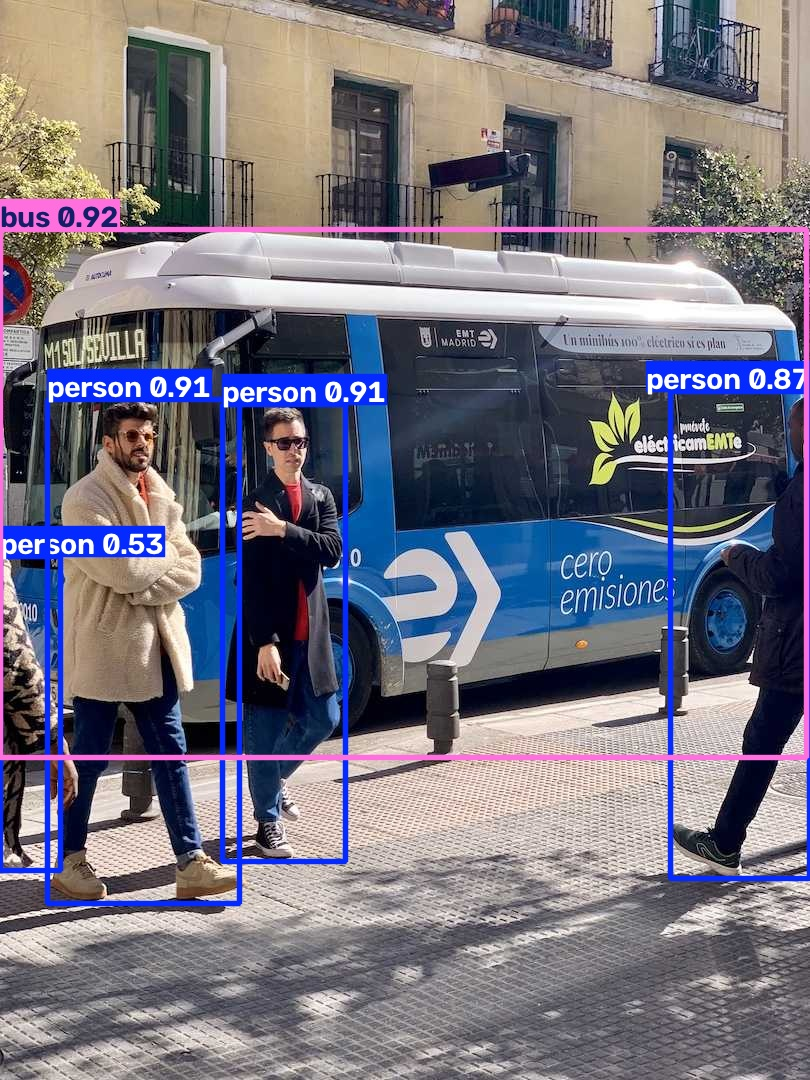

In [ ]:
!yolo predict model=yolo26n.pt source='https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg'
from IPython.display import Image
Image(filename='runs/detect/predict/bus.jpg', width=600)

In order to survive a Colab session timeout, mount a GDrive to store and retrieved datasets and models from:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Pulling the Roboflow dataset to fine-tune the model:

In [ ]:
#Find the dataset at: https://universe.roboflow.com/roboflow-100/printed-circuit-board/dataset/4
#Download the zip and move it into your drive. Make sure the names match between the commands below and the drive folder (in my case "Roboflow Datasets" is where I saved the zip)
!unzip '/content/drive/MyDrive/Roboflow Datasets/pcbv4yolo26.zip' -d '/content/pcb/' -o
!cat '/content/pcb/data.yaml'

Archive:  /content/drive/MyDrive/Roboflow Datasets/pcbv4yolo26.zip
replace /content/pcb/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/pcb/README.dataset.txt  
replace /content/pcb/README.roboflow.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/pcb/README.roboflow.txt  
replace /content/pcb/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/pcb/data.yaml  
 extracting: /content/pcb/test/images/ATTIOT_Bottom_jpg.rf.94cd89169043c7506cde7ced6de19680.jpg  
 extracting: /content/pcb/test/images/ATTIOT_Bottom_jpg.rf.a4f31e8c2d624c9e47b1e2f24ee88e69.jpg  
 extracting: /content/pcb/test/images/Arty_Bottom_jpg.rf.16f36245a0765afee4ea9dd43ae09f68.jpg  
 extracting: /content/pcb/test/images/Arty_Bottom_jpg.rf.b990509a5c76764e81f3e4e3a83b2711.jpg  
 extracting: /content/pcb/test/images/Arty_Top_jpg.rf.5d15b4645b32647b6439efa7fe4e3942.jpg  
 extracting: /content/pcb/test/images/Arty_Top_jpg.rf.7bc260a89099530b771500c983e166

Fine-tuning:

In [ ]:
!yolo detect train model=yolo26n.pt data='/content/pcb/data.yaml' epochs=100 imgsz=1280 batch=16 project='/content/drive/MyDrive/pcb-detection-yolo' name='exp1' exist_ok=True

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pcb/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, opt

Saving the highest-scoring weights across all the epochs to the drive for future use as well as the confusion matrix and results pngs:

In [ ]:
!cp '/content/drive/MyDrive/pcb-detection-yolo/exp1/weights/best.pt' '/content/drive/MyDrive/pcb-detection-yolo/best.pt'
!cp '/content/drive/MyDrive/pcb-detection-yolo/exp1/confusion_matrix.png' '/content/drive/MyDrive/pcb-detection-yolo/confusion_matrix.png'
!cp '/content/drive/MyDrive/pcb-detection-yolo/exp1/results.png' '/content/drive/MyDrive/pcb-detection-yolo/results.png'

Evaluation. I chose to report both the mAP50 and mAP50-95.

mAP50: A bounding box is counted "correct" if the IoU (area where the predicted box and actual box intersect) is >= 0.5.

mAP50-95: computes the mean average precision at ten thresholds (0.5, 0.55, 0.6... 0.95).

In [ ]:
!yolo detect val model='/content/drive/MyDrive/pcb-detection-yolo/exp1/weights/best.pt' data='/content/pcb/data.yaml'

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,379,321 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3702.1±659.7 MB/s, size: 496.2 KB)
val: Scanning /content/pcb/valid/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 12.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.8s/it 9.2s
                   all         80      18602      0.208      0.138     0.0863     0.0518
                Button         12         60      0.234      0.341      0.157      0.102
             Capacitor         40       3631      0.108      0.121     0.0305     0.0134
      Capacitor Jumper         40       3630      0.148     0.0576     0.0215    0.00896
                 Clock          6         10          0          0    0.00186    0.00112
             Connector         66        714      0.3

Performing inference on a new image:

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,379,321 parameters, 0 gradients, 5.3 GFLOPs

image 1/1 /content/drive/MyDrive/pcb-detection-yolo/pcb-inf-1.jpeg: 480x640 1 Button, 3 Capacitors, 4 ICs, 10.0ms
Speed: 18.6ms preprocess, 10.0ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


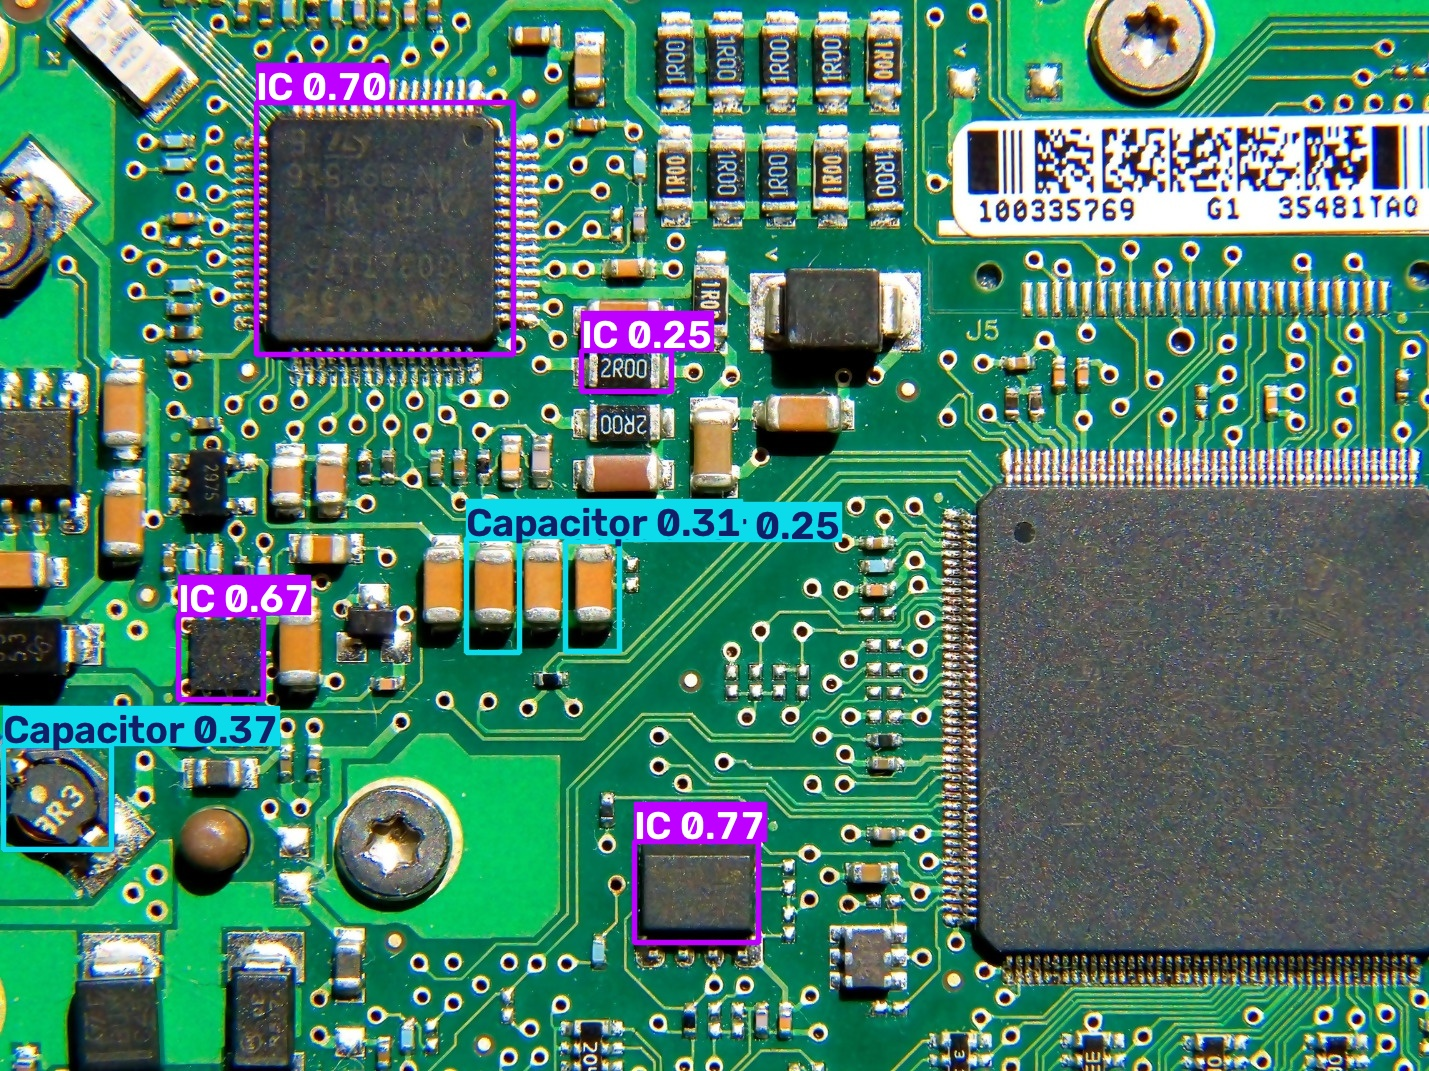

In [ ]:
!yolo detect predict model='/content/drive/MyDrive/pcb-detection-yolo/exp1/weights/best.pt' source='/content/drive/MyDrive/pcb-detection-yolo/pcb-inf-1.jpeg' exist_ok=True
Image(filename='runs/detect/predict-3/pcb-inf-1.jpg', width=600)